In [ ]:
import pandas as pd
import numpy as np
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Create full deck as list of (suit, rank) tuples
deck = [(suit, rank) for suit in suits for rank in ranks]

# Randomly select 13 unique cards
hand = random.sample(deck, 13)

# Initialize dataframe with 0s
df = pd.DataFrame(0, index=suits, columns=ranks)

# Set 1 for cards in hand
for card in hand:
    suit, rank = card
    df.loc[suit, rank] = 1

# Display the dataframe
print(df)


          Ace  King  Queen  Jack  10  9  8  7  6  5  4  3  2
Clubs       1     0      0     1   0  0  0  0  0  0  0  1  0
Diamonds    0     0      1     0   1  0  0  0  0  0  0  0  0
Hearts      1     1      0     0   1  0  1  0  0  0  1  0  0
Spades      0     0      0     0   0  1  0  0  1  0  1  0  0


In [ ]:
import pandas as pd
import numpy as np
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Create full deck as list of (suit, rank) tuples
deck = [(suit, rank) for suit in suits for rank in ranks]

# Randomly select 13 unique cards
hand = random.sample(deck, 13)

# Initialize dataframe with 0s
df = pd.DataFrame(0, index=suits, columns=ranks)

# Set 1 for cards in hand
for suit, rank in hand:
    df.loc[suit, rank] = 1

# Function to calculate zeros before first 1 and count of 1s
def analyze_row(row):
    row_list = row.tolist()
    try:
        zeros_before_first_one = row_list.index(1)
    except ValueError:
        zeros_before_first_one = len(row_list)  # 13 if no 1 exists
    count_ones = sum(row_list)
    return pd.Series([zeros_before_first_one, count_ones], index=['Zeros_Before_First_1', 'Count_1s'])

# Apply function to each row and add as new columns
df[['Zeros_Before_First_1', 'Count_1s']] = df.apply(analyze_row, axis=1)

# Display the final dataframe
print(df)

          Ace  King  Queen  Jack  10  9  8  7  6  5  4  3  2  \
Clubs       0     0      0     0   0  0  0  0  1  0  0  0  1   
Diamonds    1     0      1     0   0  0  0  0  0  0  1  1  0   
Hearts      0     0      1     0   0  0  0  0  0  0  0  1  1   
Spades      0     1      1     0   0  1  0  0  1  0  0  0  0   

          Zeros_Before_First_1  Count_1s  
Clubs                        8         2  
Diamonds                     0         4  
Hearts                       2         3  
Spades                       1         4  


Decision making

In [ ]:
import pandas as pd
import numpy as np
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Create full deck as list of (suit, rank) tuples
deck = [(suit, rank) for suit in suits for rank in ranks]

# Randomly select 13 unique cards
hand = random.sample(deck, 13)

# Initialize dataframe with 0s
df = pd.DataFrame(0, index=suits, columns=ranks)

# Set 1 for cards in hand
for suit, rank in hand:
    df.loc[suit, rank] = 1

# Function to calculate zeros before first 1 and count of 1s
def analyze_row(row):
    row_list = row.tolist()
    try:
        zeros_before_first_one = row_list.index(1)
    except ValueError:
        zeros_before_first_one = len(row_list)  # 13 if no 1 exists
    count_ones = sum(row_list)
    return pd.Series([zeros_before_first_one, count_ones], index=['Zeros_Before_First_1', 'Count_1s'])

# Apply function to each row and add as new columns
df[['Zeros_Before_First_1', 'Count_1s']] = df.apply(analyze_row, axis=1)

# Calculate total sum of zeros before first 1
total_zeros_before_first_1 = df['Zeros_Before_First_1'].sum()

# Print the dataframe
print(df)

# Decision condition
if total_zeros_before_first_1 <= 6:
    print("Go ahead")
else:
    print("Do not proceed")

          Ace  King  Queen  Jack  10  9  8  7  6  5  4  3  2  \
Clubs       0     0      0     0   0  0  1  0  0  0  1  0  1   
Diamonds    0     1      0     1   0  0  0  0  1  1  1  1  0   
Hearts      0     0      0     0   0  0  0  1  0  0  0  0  0   
Spades      0     1      0     0   0  0  0  1  1  0  0  0  0   

          Zeros_Before_First_1  Count_1s  
Clubs                        6         3  
Diamonds                     1         6  
Hearts                       7         1  
Spades                       1         3  
Do not proceed


Simulation

In [ ]:
import pandas as pd
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Create full deck as list of (suit, rank) tuples
deck = [(suit, rank) for suit in suits for rank in ranks]

# Initialize counters
go_ahead_count = 0
do_not_proceed_count = 0

# Run 100,000 simulations
for _ in range(100000):
    # Randomly select 13 unique cards
    hand = random.sample(deck, 13)

    # Initialize dataframe with 0s
    df = pd.DataFrame(0, index=suits, columns=ranks)

    # Set 1 for cards in hand
    for suit, rank in hand:
        df.loc[suit, rank] = 1

    # Calculate zeros before first 1 for each suit
    zeros_before_first_1_list = []
    for suit in suits:
        row = df.loc[suit].tolist()
        try:
            zeros_before_first_1 = row.index(1)
        except ValueError:
            zeros_before_first_1 = len(row)  # 13 if no 1 exists
        zeros_before_first_1_list.append(zeros_before_first_1)

    total_zeros_before_first_1 = sum(zeros_before_first_1_list)

    # Decision condition
    if total_zeros_before_first_1 <= 4:
        go_ahead_count += 1
    else:
        do_not_proceed_count += 1

# Print frequencies
print("Results after 100,000 simulations:")
print(f"Go ahead: {go_ahead_count}")
print(f"Do not proceed: {do_not_proceed_count}")


Results after 100,000 simulations:
Go ahead: 9438
Do not proceed: 90562


Comparison Graph

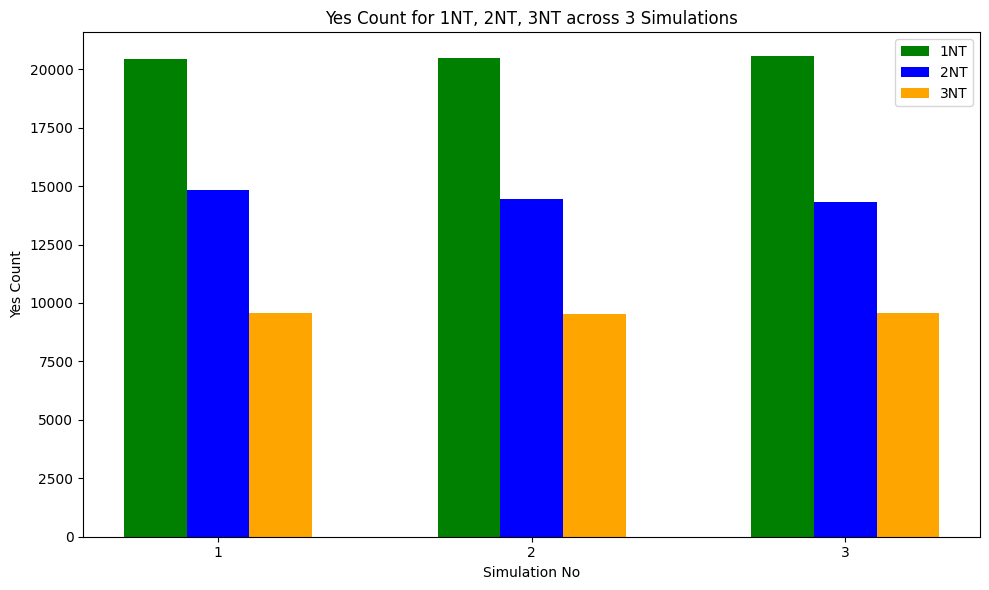

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create dataframe from your data
data = {
    'Simulation_Type': ['1NT', '1NT', '1NT', '2NT', '2NT', '2NT', '3NT', '3NT', '3NT'],
    'Simulation_No': [1, 2, 3, 1, 2, 3, 1, 2, 3],
    'Yes': [20448, 20460, 20549, 14838, 14460, 14316, 9575, 9533, 9581],
    'No': [79552, 79540, 79451, 85162, 85540, 85684, 90425, 90467, 90419]
}

df = pd.DataFrame(data)

# Pivot table to structure data for plotting
pivot_df = df.pivot(index='Simulation_No', columns='Simulation_Type', values='Yes')

# Plotting
fig, ax = plt.subplots(figsize=(10,6))

# Define bar width and positions
bar_width = 0.2
index = np.arange(len(pivot_df.index))

# Colors for different NT types
colors = ['green', 'blue', 'orange']

# Plot multiple bars
for i, sim_type in enumerate(['1NT', '2NT', '3NT']):
    ax.bar(index + i * bar_width, pivot_df[sim_type], width=bar_width, label=sim_type, color=colors[i])

# Set labels and title
ax.set_xlabel('Simulation No')
ax.set_ylabel('Yes Count')
ax.set_title('Yes Count for 1NT, 2NT, 3NT across 3 Simulations')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(pivot_df.index)
ax.legend()

plt.tight_layout()
plt.show()


Find more accuracy

In [ ]:
import pandas as pd
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Create full deck as list of (suit, rank) tuples
deck = [(suit, rank) for suit in suits for rank in ranks]

# Randomly select 13 unique cards
hand = random.sample(deck, 13)

# Initialize DataFrame with 0s
df = pd.DataFrame(0, index=suits, columns=ranks)

# Mark the 13 selected cards
for suit, rank in hand:
    df.loc[suit, rank] = 1

# Analyze each row
def analyze_row(row):
    row_list = row.tolist()
    count_ones = sum(row_list)
    if count_ones == 0:
        zeros_before = 13
        zeros_after = 0
    else:
        zeros_before = row_list.index(1)
        zeros_after = row_list[zeros_before+1:].count(0)
    return pd.Series([zeros_before, count_ones, zeros_after],
                     index=['Zeros_Before_First_1', 'Count_1s', 'Zeros_After_First_1'])

# Apply to all suits
df[['Zeros_Before_First_1', 'Count_1s', 'Zeros_After_First_1']] = df.apply(analyze_row, axis=1)

# Nested condition
total_zeros_before = df['Zeros_Before_First_1'].sum()
if total_zeros_before <= 6:
    if all(df['Count_1s'] > df['Zeros_Before_First_1']):
        decision = "Go ahead"
    else:
        decision = "Do not proceed"
else:
    decision = "Do not proceed"

# Final output
print("\nFINAL DataFrame:")
print(df)
print(f"\nDecision: {decision}")



FINAL DataFrame:
          Ace  King  Queen  Jack  10  9  8  7  6  5  4  3  2  \
Clubs       0     0      0     1   0  0  0  1  0  0  1  1  0   
Diamonds    0     1      0     0   0  0  0  0  0  0  1  0  1   
Hearts      1     0      0     0   0  0  1  0  0  0  0  1  0   
Spades      1     0      0     0   0  0  0  0  1  0  0  0  1   

          Zeros_Before_First_1  Count_1s  Zeros_After_First_1  
Clubs                        3         4                    6  
Diamonds                     1         3                    9  
Hearts                       0         3                   10  
Spades                       0         3                   10  

Decision: Go ahead


Simulation

In [ ]:
import pandas as pd
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Create full deck as list of (suit, rank) tuples
deck = [(suit, rank) for suit in suits for rank in ranks]

# Initialize counters
go_ahead_count = 0
do_not_proceed_count = 0

# Run 100,000 simulations
for _ in range(100000):
    # Randomly select 13 unique cards
    hand = random.sample(deck, 13)

    # Initialize DataFrame with 0s
    df = pd.DataFrame(0, index=suits, columns=ranks)

    # Mark the 13 selected cards
    for suit, rank in hand:
        df.loc[suit, rank] = 1

    # Analyze each row
    zeros_before_first_1_list = []
    count_1s_list = []

    for suit in suits:
        row_list = df.loc[suit].tolist()
        count_ones = sum(row_list)

        if count_ones == 0:
            zeros_before = 13
            zeros_after = 0
        else:
            zeros_before = row_list.index(1)
            zeros_after = row_list[zeros_before+1:].count(0)

        zeros_before_first_1_list.append(zeros_before)
        count_1s_list.append(count_ones)

        # For condition B check per row: Count_1s >= Zeros_Before_First_1
        if count_ones <= zeros_before:
          condition_B_failed = True
          break
    else:
        condition_B_failed = False

    # Condition A: sum of zeros before first 1 ≤ 6
    total_zeros_before = sum(zeros_before_first_1_list)

    # Nested condition check
    if total_zeros_before <= 6:
        if not condition_B_failed:
            go_ahead_count += 1
        else:
            do_not_proceed_count += 1
    else:
        do_not_proceed_count += 1

# Print frequencies summary
print("\nResults after 100,000 simulations:")
print(f"Go ahead: {go_ahead_count}")
print(f"Do not proceed: {do_not_proceed_count}")



Results after 100,000 simulations:
Go ahead: 7098
Do not proceed: 92902


Final code

In [ ]:
import pandas as pd
import random

# Step 1-2: Define suits, ranks and create full deck
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']
deck = [(suit, rank) for suit in suits for rank in ranks]

# Step 3: Randomly select 13 unique cards
hand = random.sample(deck, 13)

# Step 4: Initialize dataframe with 0s and update with hand cards
df = pd.DataFrame(0, index=suits, columns=ranks)
for suit, rank in hand:
    df.loc[suit, rank] = 1

# Function to analyze each row for zeros before first 1 and count of 1s
def analyze_row(row):
    row_list = row.tolist()
    count_ones = sum(row_list)

    if count_ones == 0:
        zeros_before_first_one = 13
    else:
        zeros_before_first_one = row_list.index(1)

    return pd.Series([zeros_before_first_one, count_ones],
                     index=['Zeros_Before_First_1', 'Count_1s'])

# Apply analysis to each row
df[['Zeros_Before_First_1', 'Count_1s']] = df.apply(analyze_row, axis=1)

# Step 5: Calculate total zeros before first 1
total_zeros_before_first_1 = df['Zeros_Before_First_1'].sum()

# Step 6: Condition A + Condition B (nested)
if total_zeros_before_first_1 <= 6:
    condition_B_passed = all(df['Count_1s'] > df['Zeros_Before_First_1'])

    if condition_B_passed:
        # Step 7: Initialize count_of_one and remaining_zeros
        count_of_one = 4
        remaining_zeros = 6 - total_zeros_before_first_1

        # While loop to traverse all 1s in all rows
        for suit in suits:
            row = df.loc[suit, ranks].tolist()
            indices_of_ones = [i for i, x in enumerate(row) if x == 1]

            # Traverse from first 1 to next 1, counting zeros between them
            for i in range(len(indices_of_ones)-1):
                zeros_between = indices_of_ones[i+1] - indices_of_ones[i] - 1

                if zeros_between <= remaining_zeros:
                    count_of_one += 1
                    remaining_zeros -= zeros_between

                # Continue while remaining_zeros >=0, break if exhausted
                if remaining_zeros < 0:
                    break

            # Break outer loop too if remaining_zeros < 0
            if remaining_zeros < 0:
                break

        # Final decision based on count_of_one
        if count_of_one >= 7:
            print("Yes, final condition satisfied. Go ahead.")
        else:
            print("No, final condition failed.")
    else:
        print("Condition B failed. Do not proceed.")
else:
    print("Condition A failed. Do not proceed.")

# Print final dataframe for verification
print("\nFinal DataFrame:")
print(df)


Yes, final condition satisfied. Go ahead.

Final DataFrame:
          Ace  King  Queen  Jack  10  9  8  7  6  5  4  3  2  \
Clubs       0     1      0     1   0  0  0  0  0  0  0  0  0   
Diamonds    0     1      0     0   0  1  0  0  1  1  1  0  0   
Hearts      0     1      0     1   0  1  0  0  0  0  1  0  0   
Spades      0     1      0     0   0  1  0  0  0  0  0  0  0   

          Zeros_Before_First_1  Count_1s  
Clubs                        1         2  
Diamonds                     1         5  
Hearts                       1         4  
Spades                       1         2  


In [ ]:
import pandas as pd
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Create full deck as list of (suit, rank) tuples
deck = [(suit, rank) for suit in suits for rank in ranks]

# Initialize counter
final_success_count = 0

# Run 100,000 simulations
for _ in range(100000):
    # Randomly select 13 unique cards
    hand = random.sample(deck, 13)

    # Initialize dataframe with 0s and update with hand cards
    df = pd.DataFrame(0, index=suits, columns=ranks)
    for suit, rank in hand:
        df.loc[suit, rank] = 1

    # Analyze each row for zeros before first 1 and count of 1s
    zeros_before_first_1_list = []
    count_1s_list = []

    for suit in suits:
        row = df.loc[suit, ranks].tolist()
        count_ones = sum(row)

        if count_ones == 0:
            zeros_before_first_one = 13
        else:
            zeros_before_first_one = row.index(1)

        zeros_before_first_1_list.append(zeros_before_first_one)
        count_1s_list.append(count_ones)

    # Step 5: Condition A
    total_zeros_before_first_1 = sum(zeros_before_first_1_list)

    if total_zeros_before_first_1 <= 3:
        # Step 6: Condition B for all rows
        condition_B_passed = all(c1 > z1 for c1, z1 in zip(count_1s_list, zeros_before_first_1_list))

        if condition_B_passed:
            # Step 7: Initialize count_of_one and remaining_zeros
            count_of_one = 4
            remaining_zeros = 3 - total_zeros_before_first_1

            for suit in suits:
                row = df.loc[suit, ranks].tolist()
                indices_of_ones = [i for i, x in enumerate(row) if x == 1]

                # Traverse from first 1 to next 1, counting zeros between them
                for i in range(len(indices_of_ones)-1):
                    zeros_between = indices_of_ones[i+1] - indices_of_ones[i] - 1

                    if zeros_between <= remaining_zeros:
                        count_of_one += 1
                        remaining_zeros -= zeros_between

                    if remaining_zeros < 0:
                        break

                if remaining_zeros < 0:
                    break

            # Final check for count_of_one >= 7
            if count_of_one >= 10:
                final_success_count += 1

# Print final simulation results
print("Results after 100,000 simulations:")
print(f"Number of successful 'Go ahead' cases: {final_success_count}")
print(f"Number of unsuccessful cases: {100000 - final_success_count}")


Results after 100,000 simulations:
Number of successful 'Go ahead' cases: 100
Number of unsuccessful cases: 99900


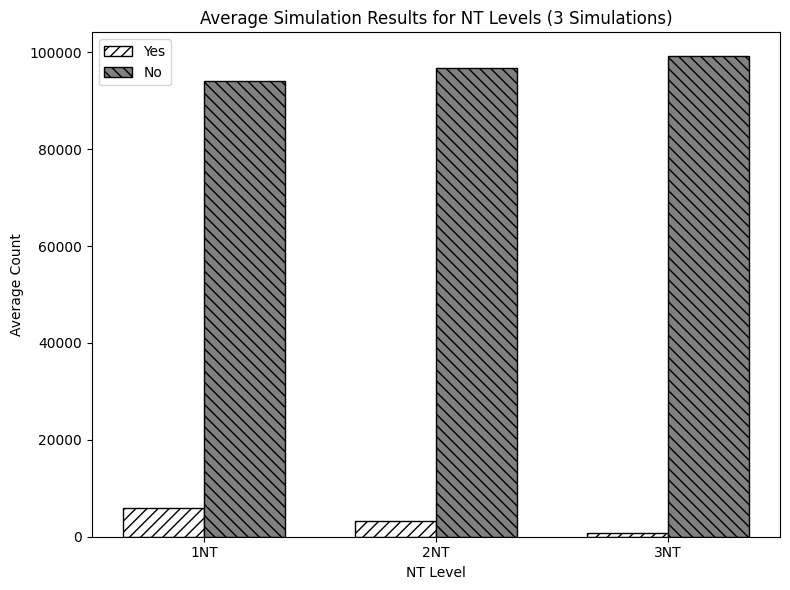

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulation data
NT_levels = ['1NT', '2NT', '3NT']
yes_counts = [
    [5955, 5992, 5849],  # 1NT
    [3228, 3174, 3186],  # 2NT
    [875, 844, 850]      # 3NT
]

no_counts = [
    [94045, 94008, 94151],  # 1NT
    [96772, 96826, 96814],  # 2NT
    [99125, 99156, 99150]   # 3NT
]

# Calculate averages
avg_yes = [np.mean(x) for x in yes_counts]
avg_no = [np.mean(x) for x in no_counts]

# Bar width and positions
x = np.arange(len(NT_levels))
width = 0.35

# Create black and white bar graph
fig, ax = plt.subplots(figsize=(8,6))

bars1 = ax.bar(x - width/2, avg_yes, width, label='Yes', color='white', edgecolor='black', hatch='///')
bars2 = ax.bar(x + width/2, avg_no, width, label='No', color='grey', edgecolor='black', hatch='\\\\\\')

# Labels and title
ax.set_xlabel('NT Level')
ax.set_ylabel('Average Count')
ax.set_title('Average Simulation Results for NT Levels (3 Simulations)')
ax.set_xticks(x)
ax.set_xticklabels(NT_levels)
ax.legend()

# Tight layout
plt.tight_layout()

# Save as PDF
plt.savefig('nt_simulation_results.pdf')

# Optional: Show plot
plt.show()


In [ ]:
import pandas as pd
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Function to check 'Go ahead' condition and return dataframe as well
def check_go_ahead(hand_cards):
    # Initialize dataframe with 0s and update with hand cards
    df = pd.DataFrame(0, index=suits, columns=ranks)
    for suit, rank in hand_cards:
        df.loc[suit, rank] = 1

    zeros_before_first_1_list = []
    count_1s_list = []

    for suit in suits:
        row = df.loc[suit, ranks].tolist()
        count_ones = sum(row)

        if count_ones == 0:
            zeros_before_first_one = 13
        else:
            zeros_before_first_one = row.index(1)

        zeros_before_first_1_list.append(zeros_before_first_one)
        count_1s_list.append(count_ones)

    # Condition A
    total_zeros_before_first_1 = sum(zeros_before_first_1_list)

    if total_zeros_before_first_1 <= 4:
        # Condition B
        condition_B_passed = all(c1 > z1 for c1, z1 in zip(count_1s_list, zeros_before_first_1_list))

        if condition_B_passed:
            count_of_one = 4
            remaining_zeros = 4 - total_zeros_before_first_1

            for suit in suits:
                row = df.loc[suit, ranks].tolist()
                indices_of_ones = [i for i, x in enumerate(row) if x == 1]

                for i in range(len(indices_of_ones)-1):
                    zeros_between = indices_of_ones[i+1] - indices_of_ones[i] - 1

                    if zeros_between <= remaining_zeros:
                        count_of_one += 1
                        remaining_zeros -= zeros_between

                    if remaining_zeros < 0:
                        break

                if remaining_zeros < 0:
                    break

            # Final check
            if count_of_one >= 9:
                return True, df
    return False, df

# Create full deck and shuffle
deck = [(suit, rank) for suit in suits for rank in ranks]
random.shuffle(deck)

# Divide to 4 players
A_hand = deck[0:13]
B_hand = deck[13:26]
C_hand = deck[26:39]
D_hand = deck[39:52]

# Check Player A only
result_A, df_A = check_go_ahead(A_hand)

# Combine Player A and D hands for 26 cards check
AD_hand = A_hand + D_hand
result_AD, df_AD = check_go_ahead(AD_hand)

# Print results
print("Results for single deal:")
print(f"Player A - 'Go ahead' result: {result_A}")
print("Player A hand dataframe:")
print(df_A)
print("\n")

print(f"Combined A+D - 'Go ahead' result: {result_AD}")
print("Combined A+D hand dataframe:")
print(df_AD)



Results for single deal:
Player A - 'Go ahead' result: False
Player A hand dataframe:
          Ace  King  Queen  Jack  10  9  8  7  6  5  4  3  2
Clubs       0     0      0     0   0  0  0  0  0  1  0  0  1
Diamonds    1     1      0     0   0  0  0  0  1  1  0  0  1
Hearts      0     0      0     0   1  0  0  1  0  1  0  0  0
Spades      0     0      1     0   0  0  1  0  1  0  0  0  0


Combined A+D - 'Go ahead' result: False
Combined A+D hand dataframe:
          Ace  King  Queen  Jack  10  9  8  7  6  5  4  3  2
Clubs       0     0      0     1   0  1  1  1  0  1  0  1  1
Diamonds    1     1      0     0   1  0  1  1  1  1  0  0  1
Hearts      1     0      1     1   1  0  0  1  0  1  0  0  1
Spades      0     0      1     0   0  0  1  0  1  0  0  1  0


In [ ]:
import pandas as pd
import random

# Define suits and ranks
suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

# Function to check 'Go ahead' condition
def check_go_ahead(hand_cards):
    # Initialize dataframe with 0s and update with hand cards
    df = pd.DataFrame(0, index=suits, columns=ranks)
    for suit, rank in hand_cards:
        df.loc[suit, rank] = 1

    zeros_before_first_1_list = []
    count_1s_list = []

    for suit in suits:
        row = df.loc[suit, ranks].tolist()
        count_ones = sum(row)

        if count_ones == 0:
            zeros_before_first_one = 13
        else:
            zeros_before_first_one = row.index(1)

        zeros_before_first_1_list.append(zeros_before_first_one)
        count_1s_list.append(count_ones)

    # Condition A
    total_zeros_before_first_1 = sum(zeros_before_first_1_list)

    if total_zeros_before_first_1 <= 1:
        # Condition B
        condition_B_passed = all(c1 > z1 for c1, z1 in zip(count_1s_list, zeros_before_first_1_list))

        if condition_B_passed:
            count_of_one = 4
            remaining_zeros = 1 - total_zeros_before_first_1

            for suit in suits:
                row = df.loc[suit, ranks].tolist()
                indices_of_ones = [i for i, x in enumerate(row) if x == 1]

                for i in range(len(indices_of_ones)-1):
                    zeros_between = indices_of_ones[i+1] - indices_of_ones[i] - 1

                    if zeros_between <= remaining_zeros:
                        count_of_one += 1
                        remaining_zeros -= zeros_between

                    if remaining_zeros < 0:
                        break

                if remaining_zeros < 0:
                    break

            # Final check
            if count_of_one >= 12:
                return True
    return False

# Initialize counters
success_count_A = 0
success_count_AD = 0

# Run 100,000 simulations
for _ in range(100000):
    # Create full deck and shuffle
    deck = [(suit, rank) for suit in suits for rank in ranks]
    random.shuffle(deck)

    # Divide to 4 players
    A_hand = deck[0:13]
    B_hand = deck[13:26]
    C_hand = deck[26:39]
    D_hand = deck[39:52]

    # Check Player A only
    if check_go_ahead(A_hand):
        success_count_A += 1

    # Combine Player A and D hands for 26 cards check
    AD_hand = A_hand + D_hand

    if check_go_ahead(AD_hand):
        success_count_AD += 1

# Print final results
print("Results after 100,000 simulations:")
print(f"Player A - Number of successful 'Go ahead' cases: {success_count_A}")
print(f"Player A - Number of unsuccessful cases: {100000 - success_count_A}")

print(f"Combined A+D - Number of successful 'Go ahead' cases: {success_count_AD}")
print(f"Combined A+D - Number of unsuccessful cases: {100000 - success_count_AD}")


Results after 100,000 simulations:
Player A - Number of successful 'Go ahead' cases: 0
Player A - Number of unsuccessful cases: 100000
Combined A+D - Number of successful 'Go ahead' cases: 17180
Combined A+D - Number of unsuccessful cases: 82820


In [ ]:
import pandas as pd
import itertools
import random
from collections import Counter

# -------------------- First Code Functions --------------------

# Define card ranks and their respective points
RANKS = "A K Q J 10 9 8 7 6 5 4 3 2".split()
SUITS = "Spades Hearts Diamonds Clubs".split()
POINTS = {"A": 5, "K": 4, "Q": 3, "J": 2, "10": 1}

# Function to generate a deck
def generate_deck():
    return list(itertools.product(RANKS, SUITS))

# Function to deal hands to players
def deal_cards():
    deck = generate_deck()
    random.shuffle(deck)
    return [deck[i::4] for i in range(4)]

# Function to evaluate hand points
def evaluate_points(hand):
    return sum(POINTS.get(card[0], 0) for card in hand)

# Function to determine the bid
def determine_bid(points):
    if points >= 30:
        return 3  # 3 No Trump
    elif points >= 25:
        return 2  # 2 No Trump
    elif points >= 20:
        return 1  # 1 No Trump
    return 0  # Pass

# -------------------- Second Code Function (DataFrame based) --------------------

def check_go_ahead(hand_cards, K, P):
    suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
    ranks = ['Ace', 'King', 'Queen', 'Jack', '10', '9', '8', '7', '6', '5', '4', '3', '2']

    # Initialize dataframe with 0s and update with hand cards
    df = pd.DataFrame(0, index=suits, columns=ranks)
    for rank, suit in hand_cards:   # Corrected order unpacking
        df.loc[suit, rank] = 1

    # Function to analyze each row
    def analyze_row(row):
        row_list = row.tolist()
        count_ones = sum(row_list)
        zeros_before_first_one = row_list.index(1) if 1 in row_list else 13
        return pd.Series([zeros_before_first_one, count_ones],
                         index=['Zeros_Before_First_1', 'Count_1s'])

    # Apply analysis
    df[['Zeros_Before_First_1', 'Count_1s']] = df.apply(analyze_row, axis=1)

    # Calculate total zeros before first 1
    total_zeros_before_first_1 = df['Zeros_Before_First_1'].sum()

    # Condition A
    if total_zeros_before_first_1 <= K:
        # Condition B
        condition_B_passed = all(df['Count_1s'] > df['Zeros_Before_First_1'])

        if condition_B_passed:
            count_of_one = 4
            remaining_zeros = K - total_zeros_before_first_1

            for suit in suits:
                row = df.loc[suit, ranks].tolist()
                indices_of_ones = [i for i, x in enumerate(row) if x == 1]

                for i in range(len(indices_of_ones)-1):
                    zeros_between = indices_of_ones[i+1] - indices_of_ones[i] - 1

                    if zeros_between <= remaining_zeros:
                        count_of_one += 1
                        remaining_zeros -= zeros_between

                    if remaining_zeros < 0:
                        break

                if remaining_zeros < 0:
                    break

            return count_of_one >= P
    return False

# -------------------- Comparison Simulation --------------------

def comparison_simulation(num_simulations=10000):
    thresholds = {
        1: {'K':6, 'P':7},
        2: {'K':5, 'P':8},
        3: {'K':4, 'P':9}
    }

    results = {nt: {'algo1':0, 'algo2':0} for nt in thresholds}

    for _ in range(num_simulations):
        hands = deal_cards()
        player_A_hand = hands[0]

        # First Algorithm - Point based
        points = evaluate_points(player_A_hand)
        bid = determine_bid(points)

        # Second Algorithm - DataFrame based with K and P per NT
        for nt in thresholds:
            K = thresholds[nt]['K']
            P = thresholds[nt]['P']

            # Check if first algo bid matches current NT level
            if bid == nt:
                results[nt]['algo1'] += 1

            # Check if second algo returns go ahead
            if check_go_ahead(player_A_hand, K, P):
                results[nt]['algo2'] += 1

    # Print comparison results
    print(f"\nComparison Results over {num_simulations} simulations:")
    for nt in thresholds:
        print(f"\n{nt} NT:")
        print(f"  Algorithm 1 (Point based) - Go ahead count: {results[nt]['algo1']}")
        print(f"  Algorithm 2 (DataFrame based) - Go ahead count: {results[nt]['algo2']}")

# Run the comparison simulation
comparison_simulation()



Comparison Results over 10000 simulations:

1 NT:
  Algorithm 1 (Point based) - Go ahead count: 1526
  Algorithm 2 (DataFrame based) - Go ahead count: 0

2 NT:
  Algorithm 1 (Point based) - Go ahead count: 396
  Algorithm 2 (DataFrame based) - Go ahead count: 0

3 NT:
  Algorithm 1 (Point based) - Go ahead count: 33
  Algorithm 2 (DataFrame based) - Go ahead count: 0
